# 04 — RFM Customer Segmentation

Computes Recency, Frequency, and Monetary scores for every customer and
assigns each to one of seven business segments:

- VIP
- Loyal
- Potential Loyal
- New
- At Risk
- Dormant
- Lost

Full logic lives in `src/segmentation.py`.


In [1]:

result = run_script("segmentation.py")

if result.returncode != 0:
    print("Segmentation failed.")


RFM Segment Summary:
        segment  customers  total_revenue  churn_rate  pct_of_customers  pct_of_revenue
        Dormant      10816     2579278.07        0.00             20.80           26.03
            VIP       7083     2561912.74        1.13             13.62           25.86
          Loyal       8832     1948651.06        5.36             16.98           19.67
           Lost       9277     1142700.75      100.00             17.84           11.53
Potential Loyal      11848     1079961.96        6.44             22.78           10.90
            New       3437      315669.55        4.10              6.61            3.19
        At Risk        707      280272.04        0.00              1.36            2.83

Saved detailed segments to C:\Users\ayuu1\Desktop\customer-retention-intelligence\customer-retention-intelligence\outputs\tables\customer_segments.csv
Saved segment summary to C:\Users\ayuu1\Desktop\customer-retention-intelligence\customer-retention-intelligence\outputs\tab

## Visualize segment sizes and revenue contribution

        segment  customers  total_revenue  churn_rate  pct_of_customers  pct_of_revenue
Potential Loyal      11848     1079961.96        6.44             22.78           10.90
        Dormant      10816     2579278.07        0.00             20.80           26.03
           Lost       9277     1142700.75      100.00             17.84           11.53
          Loyal       8832     1948651.06        5.36             16.98           19.67
            VIP       7083     2561912.74        1.13             13.62           25.86
            New       3437      315669.55        4.10              6.61            3.19
        At Risk        707      280272.04        0.00              1.36            2.83


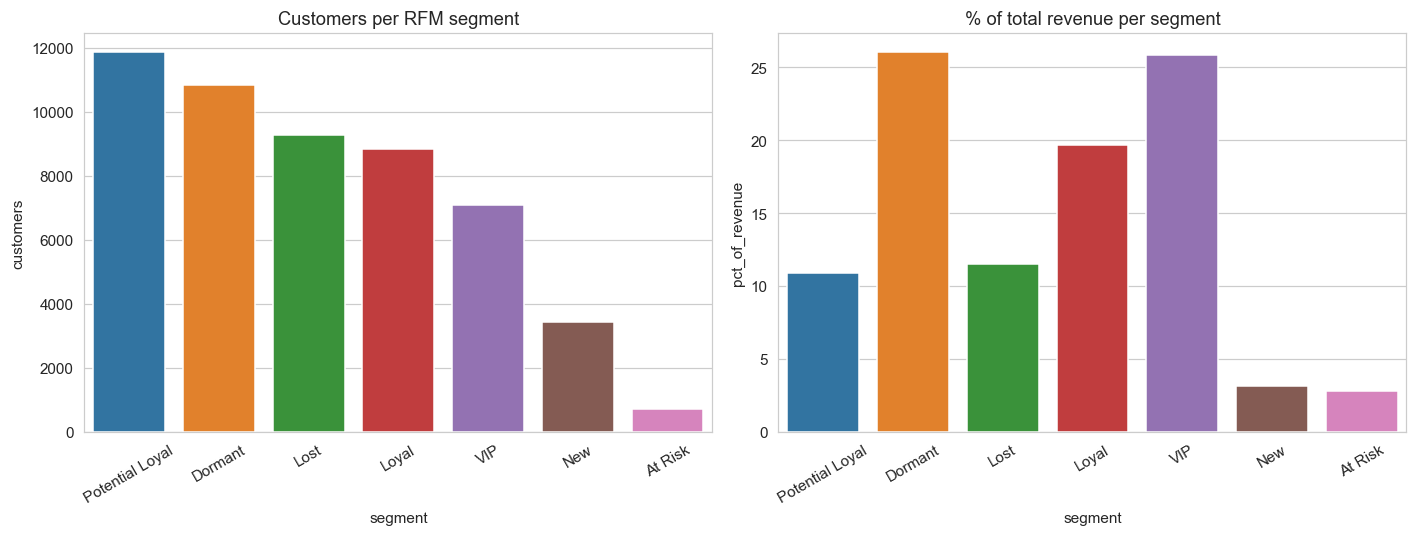

In [2]:

import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

summary = pd.read_csv(
    ROOT / "outputs" / "tables" / "segment_summary.csv"
)

summary = summary.sort_values(
    "customers",
    ascending=False
)

print(
    summary.to_string(index=False)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.barplot(
    data=summary,
    x="segment",
    y="customers",
    hue="segment",
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Customers per RFM segment"
)

axes[0].tick_params(
    axis="x",
    rotation=30
)

sns.barplot(
    data=summary,
    x="segment",
    y="pct_of_revenue",
    hue="segment",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "% of total revenue per segment"
)

axes[1].tick_params(
    axis="x",
    rotation=30
)

plt.tight_layout()

plt.show()


### Segment churn rates

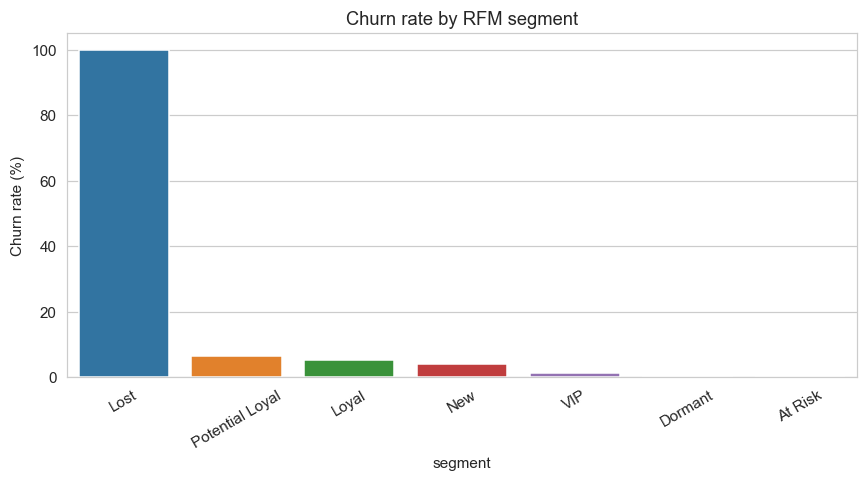

In [3]:

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

summary_sorted = summary.sort_values(
    "churn_rate",
    ascending=False
)

sns.barplot(
    data=summary_sorted,
    x="segment",
    y="churn_rate",
    hue="segment",
    legend=False,
    ax=ax
)

ax.set_ylabel(
    "Churn rate (%)"
)

ax.set_title(
    "Churn rate by RFM segment"
)

ax.tick_params(
    axis="x",
    rotation=30
)

plt.tight_layout()

plt.show()


**Takeaway:** The `Lost` segment is churned by definition (100%).
`Loyal` and `Potential Loyal` customers represent meaningful retention
opportunities. RFM recency should be interpreted alongside billing cycle.